# DWT Application Example: Audio file

Download a .wav file.

Decompose the signal in low and high frequencies by using DWT.

Then write the following files:

1. The fully reconstructed signal from the approximation and detail coefficients.


2. The low-frequency signal considering the approximation coefficients only.


3. The high-frequency signal considering the detail coefficients only.


4. Listen to all three audio tracks and compare them to the original one. What do you find?

### Reference file:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/ImperialMarch60.wav

In [1]:
from scipy.io import wavfile

import IPython.display as ipd

import numpy as np

import matplotlib.pyplot as plt

import pywt

### Read wav file:

In [2]:
# Define file path

filepath = "./"

# File I/O 
samplerate, data = wavfile.read(filepath + "ImperialMarch60.wav")

In [3]:
# Check the signal

print(type(samplerate))

print(data.shape)

print(np.min(data), np.max(data))

<class 'int'>
(1323000,)
-31961 31031


In [4]:
#ipd.Audio(filepath + "ImperialMarch60.wav")

### Define x and y axes:

In [5]:
# Generate the time axis using the sampling rate
t = np.arange(len(data))/float(samplerate)

# Normalising the signal
data = data/np.max(data)

### Plot signal:

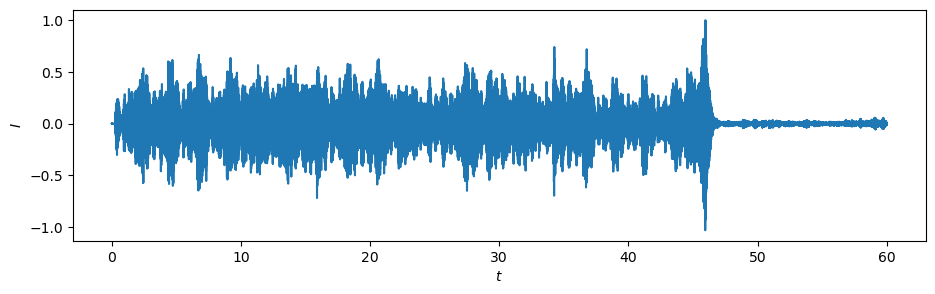

In [6]:
# Plotting the audio track

plt.figure(figsize=(11,3))

plt.plot(t, data)

plt.xlabel(r"$t$")
plt.ylabel(r"$I$")
#plt.xlim(0,2)
plt.show()

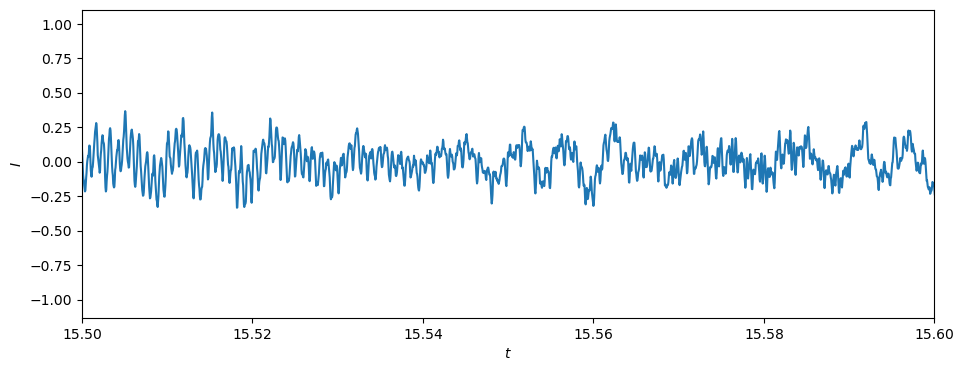

In [7]:
# Plotting the audio track

plt.figure(figsize=(11,4))

plt.plot(t, data)
plt.xlim(15.5,15.6)

plt.xlabel(r"$t$")
plt.ylabel(r"$I$")
plt.show()

### DWT to get coefficients:

In [8]:
cA, cD = pywt.dwt(data, 'bior6.8', 'per')

print(cA.shape, cD.shape, data.shape)

(661500,) (661500,) (1323000,)


In [9]:
# Applying the iDWT
data_reconstruted = pywt.idwt(cA, cD, 'bior6.8', 'per')

# Saving the reconstructed file
wavfile.write(filepath + 'full_reconstructed.wav', samplerate, data_reconstruted)


In [10]:
wavfile.write('./reconstructed.wav', samplerate, data_reconstruted)



### Comparing the original and the reconstructured signals:

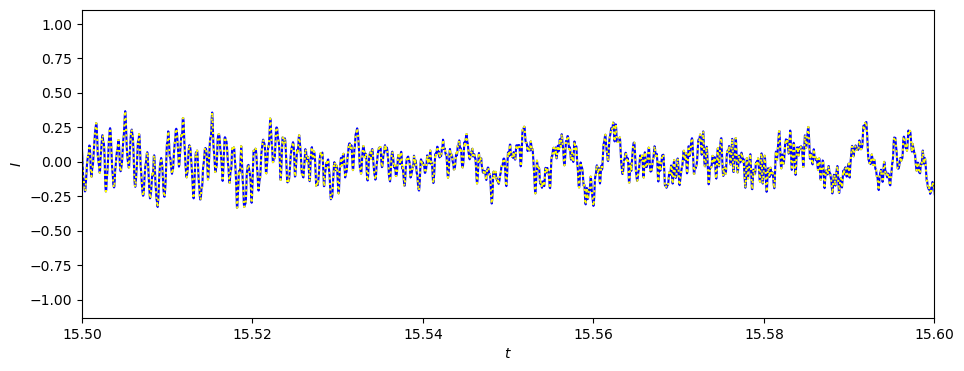

In [11]:
plt.figure(figsize=(11,4))

plt.plot(t, data, "blue")
plt.plot(t, data_reconstruted, linestyle = ":", c="yellow")
plt.xlim(15.5,15.6)

plt.xlabel(r"$t$")
plt.ylabel(r"$I$")
plt.show()

In [12]:
samplerate1, data1 = wavfile.read(filepath + "full_reconstructed.wav")

print(samplerate1)

print(data1.shape)

22050
(1323000,)


In [13]:
#ipd.Audio(filepath + "full_reconstructed.wav")

#### Isolate the low frequencies (Approximation coefficients)



In [14]:
# Saving the low freq. directly
wavfile.write(filepath + 'only_ca.wav', samplerate, cA) 

# 2nd try:
data_low = pywt.idwt(cA, None, "bior6.8", "per")

# Formatting: https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html

data_low_f = np.clip(data_low, -1., +1.).astype(np.float32)
 
#wavfile.write(filepath + 'only_ca2.wav', samplerate, data_low)
wavfile.write(filepath + 'only_ca3.wav', samplerate, data_low_f)

In [15]:
#ipd.Audio(filepath + "only_ca3.wav")

#### Isolate the high frequencies (Detailed coefficients)

In [16]:
# Saving the low freq. directly
#wavfile.write(filepath + 'only_cd.wav', samplerate, cD) 


# 2nd try:
data_high = pywt.idwt(None, cD, "bior6.8", "per")

# Formatting: https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.read.html

data_high_f = np.clip(data_high, -1., +1.).astype(np.float32)

wavfile.write(filepath + 'only_cd2.wav', samplerate, data_high)
wavfile.write(filepath + 'only_cd3.wav', samplerate, data_high_f)

In [17]:
#ipd.Audio(filepath + "only_cd3.wav")

#wavfile.write('../sample-data/with_only_cds.wav', samplerate, cD) #high freq.

### Alternative decomposition with pywt.wavedec():

In [18]:
coeffs_audio = pywt.wavedec(data, 'bior6.8', level = 2, mode = 'periodic')

#print(len(coeffs_audio))

ca, cd2, cd1 = coeffs_audio

In [19]:
print("Signal size: ", data.shape)
print("1 level: ", data.shape[0]//2)
print("2 level: ", data.shape[0]//4)

Signal size:  (1323000,)
1 level:  661500
2 level:  330750


In [20]:
print("Second level cA: ", ca.shape)
print("First level cD1: ",  cd1.shape)
print("Second level cD2: ", cd2.shape)
#print(cd3.shape)
#print(cd4.shape)

Second level cA:  (330762,)
First level cD1:  (661508,)
Second level cD2:  (330762,)


### Recovering the original signal with pywt.waverec()

In [21]:
# Let's get the original signal again:

recovered_audio = pywt.waverec(coeffs_audio, 'bior6.8', mode = 'periodic')

In [22]:
wavfile.write(filepath + 'full_reconstructed2.wav', samplerate, recovered_audio)

### Only using cA (2nd level):

In [23]:
print(len(coeffs_audio))
print(coeffs_audio[-3])

3
[-0.01701625 -0.00747072 -0.0033645  ... -0.00846257 -0.00272453
  0.00043564]


In [24]:
# Removing the second level detail coefficients
coeffs_audio[-2] = np.zeros_like(coeffs_audio[-2])

# Removing the first level detail coefficients
coeffs_audio[-1] = np.zeros_like(coeffs_audio[-1])

In [25]:
# Only cA coeff.

recovered_audio_ca = pywt.waverec(coeffs_audio, 'bior6.8', mode = 'periodic')

In [26]:
wavfile.write(filepath + 'rec_ca2.wav', samplerate, recovered_audio_ca)

### Alternative decomposition with pywt.wavedec():

In [27]:
coeffs_audio = pywt.wavedec(data, 'bior6.8', level = 3, mode = 'periodic')

print(len(coeffs_audio))

ca, cd3, cd2, cd1 = coeffs_audio

4


In [28]:
print("Third level cA: ", ca.shape)
print("First level cD1: ",  cd1.shape)
print("Second level cD2: ", cd2.shape)
print("Third level cD3: ", cd3.shape)
#print(cd3.shape)
#print(cd4.shape)

Third level cA:  (165389,)
First level cD1:  (661508,)
Second level cD2:  (330762,)
Third level cD3:  (165389,)


In [29]:
# Removing the third level detail coefficients
coeffs_audio[-3] = np.zeros_like(coeffs_audio[-3])

# Removing the second level detail coefficients
coeffs_audio[-2] = np.zeros_like(coeffs_audio[-2])

# Removing the first level detail coefficients
coeffs_audio[-1] = np.zeros_like(coeffs_audio[-1])

In [30]:
# Only cA coeff.

recovered_audio_ca = pywt.waverec(coeffs_audio, 'bior6.8', mode = 'periodic')

In [31]:
wavfile.write(filepath + 'rec_ca3.wav', samplerate, recovered_audio_ca)

### Reconstructing third level high-freq components:

In [32]:
coeffs_audio = pywt.wavedec(data, 'bior6.8', level = 3, mode = 'periodic')

print(len(coeffs_audio))

ca, cd3, cd2, cd1 = coeffs_audio

4


In [33]:
# Removing the third level approx coefficients
coeffs_audio[0] = np.zeros_like(coeffs_audio[0])

# Removing the second level detail coefficients
#coeffs_audio[-2] = np.zeros_like(coeffs_audio[-2])

# Removing the first level detail coefficients
#coeffs_audio[-1] = np.zeros_like(coeffs_audio[-1])

In [34]:
# Only cA coeff.

recovered_audio_ca = pywt.waverec(coeffs_audio, 'bior6.8', mode = 'periodic')

In [35]:
wavfile.write(filepath + 'rec_cd3.wav', samplerate, recovered_audio_ca)